## Introducing Deep Neural Networks 

## Used libraries

In [1]:
from AmaroX.AmaroX.ai_functions import * 
from AmaroX.AmaroX.ai_models import * 
from AmaroX.AmaroX.data_manipulation import *
from AmaroX.AmaroX.utilities import *

import keras_tuner
import pandas as pd

2025-09-25 21:28:20.122382: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-25 21:28:20.970816: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/gaussian//g16/bsd:/opt/gaussian//g16:/opt/TeraChem/TeraChem/lib:/usr/local/cuda/lib64:/opt/intel/oneapi/vtune/2023.2.0/lib64/:/opt/intel/oneapi/tbb/2021.10.0/env/../lib/intel64/gcc4.8:/opt/intel/oneapi/mpi/2021.10.0//libfabric/lib:/opt/intel/oneapi/mpi/2021.10.0//lib/release:/opt/intel/oneapi/mpi/2021.10.0//lib:/opt/intel/oneapi/mkl/2023.2.0/lib/

## 1/10 Samples

In [2]:
n = 10
size = [
    1080000//n,
    108000//n, 
    12000//n
]

In [3]:
data = load_data_normalization_sample_General(
    '../../../../data_simulation/F2', 
    size = size
)

In [4]:
show_dimensions(data)


--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train: 
    x: (108000, 911, 1)
    y: (108000, 1)

Test: 
    x: (10800, 911, 1)
    y: (10800, 1)

Val:
    x: (1200, 911, 1)
    y: (1200, 1)
    


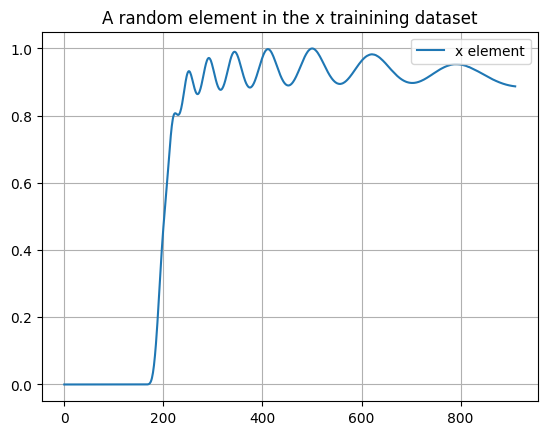

The corresponding y element -> [1058.6067]


In [5]:
plot_xy(data)

In [6]:
x_train, y_train, x_test, y_test, x_val, y_val = data
del data 

## GPU Allocation

In [7]:
get_gpu(0)

2025-09-25 21:28:44.078564: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-25 21:28:44.954226: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30971 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


## Paths

In [9]:
name = 'DNN_HP_3'
folder_path = './models'
final_path = os.path.join(folder_path, name)

## Callbacks

In [10]:
callbacks = standard_callbacks(folder_name= name, 
                               folder_path= folder_path, 
                               patiences= [50, 1000])

## DNN Model

In [11]:
def _DNN(nodes:list):

    inputs = keras.layers.Input((911,))

    __DNN = G_Dense(
        inputs = inputs, 
        nodes = nodes,
        DP = 0,
        n_final = 1,
        act_func = 'leaky_relu', 
        final_act_func= 'relu', 
        WI= 'he_normal', 
        L1 = 0.0, 
        L2 = 0.0, 
        use_bias= True
    )

    return keras.models.Model(inputs = inputs, outputs = __DNN)

In [14]:
def compile_model(nodes: list, optimizer, modelo):

  model = modelo(nodes = nodes)

  model.compile(optimizer = optimizer,
                loss = 'mae',
                metrics = ['mape'])

  return model

In [15]:
def build_model(hp):

  nodes = [
      hp.Int('Nodes-1', min_value = 50, max_value = 500, step = 50), 
      hp.Int('Nodes-2', min_value = 50, max_value = 500, step = 50),
      hp.Int('Nodes-3', min_value = 50, max_value = 500, step = 50),
      #hp.Int('Nodes-4', min_value = 1, max_value = 500, step = 50),
      #hp.Int('Nodes-5', min_value = 1, max_value = 500, step = 50),
  ]

  #DP = hp.Int('Dropout', min_value = 0, max_value = 50, step = 2)

  #L1 = hp.Choice('L1', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  #L2 = hp.Choice('L2', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  optimizer = hp.Choice('optimizer', ['adam'])

  if optimizer == 'adam': opt = keras.optimizers.Adam(
        learning_rate = 0.001
    )

  elif optimizer == 'sgd': opt = keras.optimizers.SGD(
        learning_rate = 0.001
    )

  elif optimizer == 'adagrad': opt = keras.optimizers.Adagrad(
        learning_rate = 0.001
    )


  model_f = compile_model(nodes = nodes, optimizer = optimizer, modelo = _DNN)

  return model_f

In [16]:
build_model(keras_tuner.HyperParameters())

In [18]:
tuner = keras_tuner.BayesianOptimization(
    hypermodel=build_model,
    objective= keras_tuner.Objective('val_mape', 'min') ,
    max_trials= 1, # Set to 3
    executions_per_trial = 2,
    overwrite=True,
    directory= final_path,
    project_name="DNN3-MI-KT",
)

In [19]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
Nodes-1 (Int)
{'default': None, 'conditions': [], 'min_value': 50, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-2 (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
Nodes-3 (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 500, 'step': 50, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam'], 'ordered': False}


In [21]:
tuner.search(x_train[:,:,0], y_train, epochs=25, validation_data=(x_test[:,:,0], y_test), batch_size=512)

Trial 1 Complete [00h 04m 05s]
val_mape: 30.304553031921387

Best val_mape So Far: 30.304553031921387
Total elapsed time: 00h 04m 05s


In [22]:
file_path = os.path.join(final_path, 'best_models.txt')

with open(file_path, "w") as file:
    # Save the original stdout
    original_stdout = sys.stdout
    try:
        sys.stdout = file  # Redirect stdout to the file
        tuner.results_summary()  # Call your function
    finally:
        sys.stdout = original_stdout

